Librerias

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import xgboost as xgb

import matplotlib.pyplot as plt

Figuras

In [ ]:
def plot_predictions(y_true, y_pred, model_name="Model"):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Perfect prediction')
    plt.xlabel("Actual % CARBON")
    plt.ylabel("Predicted % CARBON")
    plt.title(f"{model_name}: Predicted vs. Actual")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Preparación de datos

In [ ]:
df = pd.read_excel('Base de datos.xlsx')

df.head(5)

,Unnamed: 0,ID Árbol,Especie,DAP (cm),Biomasa estimada (kg),Carbono,Salinidad,pH
0,Equipo 1,1,Avicennia germinans,43.0,1884.572967,866.903565,35,2025-08-06 00:00:00
1,NaN,2,Avicennia germinans,41.0,1679.408040,772.527698,35,2025-08-06 00:00:00
2,NaN,3,Avicennia germinans,43.0,1884.572967,866.903565,35,2025-08-06 00:00:00
3,NaN,4,Avicennia germinans,66.0,5315.151143,2444.969526,35,2025-08-06 00:00:00
4,NaN,5,Avicennia germinans,66.0,5315.151143,2444.969526,35,2025-08-06 00:00:00


In [ ]:
#Features and target
features = ['Especie', 'Biomasa estimada (kg)', 'DAP (cm)']
target = 'Carbono'

X = df[features]        #predictores
y = df[target]          #lo que queremos predecir

# Columnas
categorical = ['Especie']
numerical = ['Biomasa estimada (kg)', 'DAP (cm)']

#Codificador, pasar la info categorica a numerica
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(X[categorical])

X_num = X[numerical].values
X_all = np.hstack((X_cat, X_num))

# Train-test split; separar la base de datos en lo que vamos a entrenar y sobre lo que vamos a probar
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2)

Decision Tree

Decision Tree RMSE: 85.49344005561977


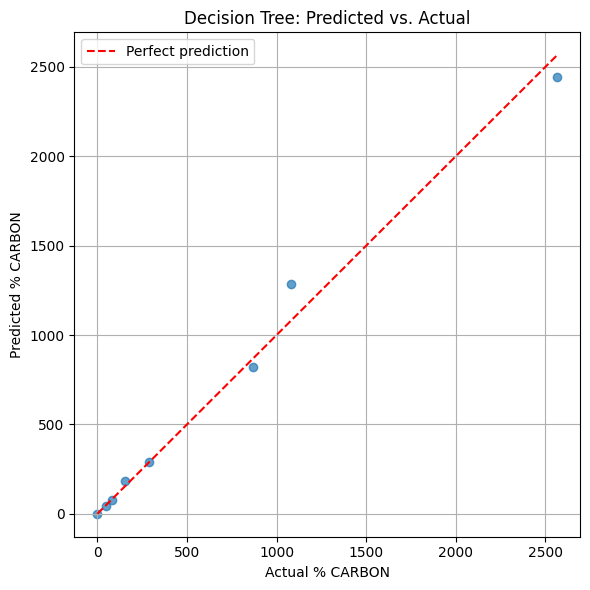

In [ ]:
dt = DecisionTreeRegressor(max_depth=10)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
print("Decision Tree RMSE:", rmse)

plot_predictions(y_test, y_pred_dt, "Decision Tree")

Random Forest

Random Forest RMSE: 247.2010993044315


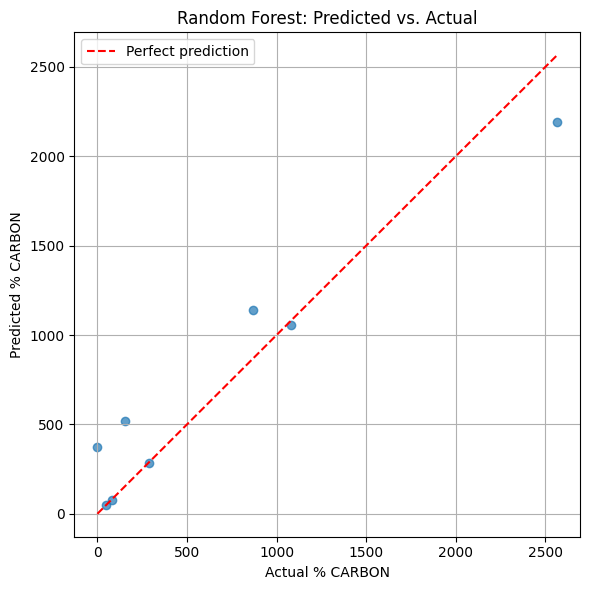

In [ ]:
rf = RandomForestRegressor(n_estimators=500)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse)

plot_predictions(y_test, y_pred_rf, "Random Forest")

XGBoost

XGBoost RMSE: 301.3941038244399


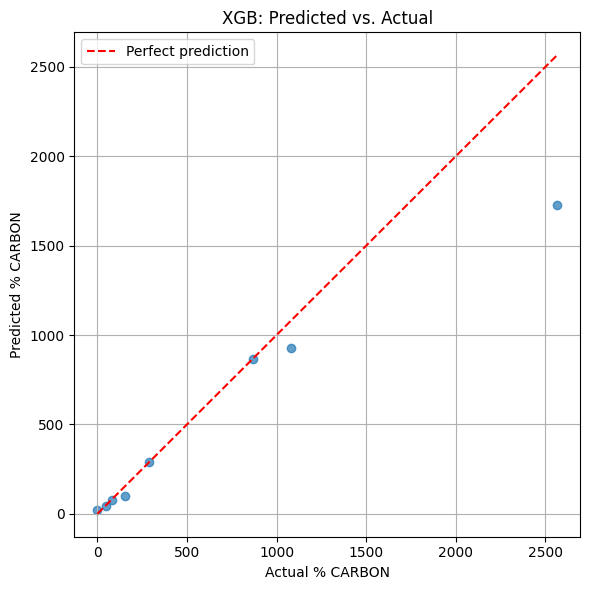

In [ ]:
model_xgb = xgb.XGBRegressor(n_estimators=500, max_depth=10, learning_rate=0.1)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("XGBoost RMSE:", rmse)

plot_predictions(y_test, y_pred_xgb, "XGB")